# Stratified Sampling — Dataset Program Makan Bergizi Gratis (MBG)

**Notebook:** `01_stratified_sampling.ipynb`  
**Peneliti:** [Nama Peneliti]  
**Tanggal:** [Tanggal Pengerjaan]  
**Deskripsi:** Notebook ini melakukan stratified sampling terhadap data tweet terkait Program Makan Bergizi Gratis (MBG) yang telah melalui validasi awal. Tujuannya adalah mengambil sampel yang representatif dari setiap bulan dalam rentang 6 Januari 2025 hingga 6 Januari 2026, sebagai data primer yang akan dilabeli secara manual untuk keperluan analisis sentimen.

---

## Latar Belakang Metodologi

Pengambilan sampel menggunakan pendekatan **equal allocation stratified sampling** berdasarkan bulan. Pendekatan ini dipilih karena:

1. **Representasi temporal yang seimbang**: Setiap bulan dalam satu tahun implementasi program MBG diwakili secara proporsional, sehingga analisis sentimen dapat mencerminkan dinamika opini publik sepanjang waktu.
2. **Justifikasi statistik**: Berdasarkan formula Slovin dengan margin error 5%, jumlah sampel minimum untuk populasi ~10.000 per bulan adalah 385 sampel. Target 500 sampel per bulan telah melampaui batas minimum ini.
3. **Penanganan bulan low-volume**: Bulan dengan jumlah tweet tersedia < 500 (terutama periode awal dan periode rendah aktivitas) diambil seluruhnya (sensus parsial) untuk memaksimalkan representasi.

**Referensi:**  
- Slovin, E. (1960). Slovin's formula for sampling technique. *Heritage of Sociology*.  
- Krejcie, R. V., & Morgan, D. W. (1970). Determining sample size for research activities. *Educational and Psychological Measurement*, 30(3), 607–610.

## 0. Setup & Mount Google Drive

Sel ini melakukan mounting Google Drive untuk mengakses data raw dan menyimpan hasil output. Pastikan akun Google yang digunakan memiliki akses ke folder `skripsi/dataset/mbg/`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Seed untuk reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Library berhasil dimuat.')
print(f'Pandas version  : {pd.__version__}')
print(f'NumPy version   : {np.__version__}')

Mounted at /content/drive
Library berhasil dimuat.
Pandas version  : 2.2.2
NumPy version   : 2.0.2


## 1. Konfigurasi Path & Parameter Sampling

Mendefinisikan seluruh path file dan parameter sampling secara terpusat agar mudah dimodifikasi tanpa mengubah logika kode di sel berikutnya.

**Parameter utama:**
- `SAMPLE_PER_MONTH = 500`: Jumlah sampel target per bulan berdasarkan justifikasi Slovin.
- `DATE_START` / `DATE_END`: Batas rentang tanggal sesuai periode crawling data.
- `MIN_WORD_COUNT = 3`: Tweet dengan jumlah kata ≤ 3 dieliminasi sebagai noise.

In [3]:
# ── PATH KONFIGURASI ──────────────────────────────────────────────────────────
BASE_DIR    = '/content/drive/My Drive/skripsi/dataset/mbg'
INPUT_PATH  = f'{BASE_DIR}/merged_data/merged_mbg_full.csv'
OUTPUT_DIR  = f'{BASE_DIR}/processed'
OUTPUT_PATH = f'{OUTPUT_DIR}/mbg_sampled.csv'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── PARAMETER SAMPLING ────────────────────────────────────────────────────────
SAMPLE_PER_MONTH = 500
DATE_START       = '2025-01-06'
DATE_END         = '2026-01-06'
MIN_WORD_COUNT   = 3

# Kolom yang digunakan dari raw data
COLS_KEEP = [
    'id_str', 'conversation_id_str', 'created_at',
    'full_text', 'username', 'user_id_str',
    'favorite_count', 'retweet_count', 'reply_count', 'quote_count',
    'lang', 'location', 'source_keyword'
]

print('Konfigurasi berhasil dimuat.')
print(f'Input  : {INPUT_PATH}')
print(f'Output : {OUTPUT_PATH}')
print(f'Sampel per bulan : {SAMPLE_PER_MONTH}')
print(f'Rentang tanggal  : {DATE_START} s/d {DATE_END}')

Konfigurasi berhasil dimuat.
Input  : /content/drive/My Drive/skripsi/dataset/mbg/merged_data/merged_mbg_full.csv
Output : /content/drive/My Drive/skripsi/dataset/mbg/processed/mbg_sampled.csv
Sampel per bulan : 500
Rentang tanggal  : 2025-01-06 s/d 2026-01-06


## 2. Load & Inspeksi Data

Memuat data dari Google Drive dan melakukan inspeksi awal untuk memahami struktur, tipe data, dan kondisi umum dataset sebelum proses sampling dilakukan.

In [4]:
print('Memuat data raw...')
df_raw = pd.read_csv(INPUT_PATH, low_memory=False)

print(f'\n=== INSPEKSI AWAL ===')
print(f'Shape            : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print(f'Kolom            : {list(df_raw.columns)}')
print(f'\nTipe data:')
print(df_raw.dtypes)
print(f'\nJumlah nilai null per kolom:')
print(df_raw.isnull().sum())
print(f'\nContoh data (3 baris pertama):')
df_raw.head(3)

Memuat data raw...

=== INSPEKSI AWAL ===
Shape            : 119,380 baris × 16 kolom
Kolom            : ['conversation_id_str', 'created_at', 'favorite_count', 'full_text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username', 'source_keyword']

Tipe data:
conversation_id_str          int64
created_at                  object
favorite_count               int64
full_text                   object
id_str                       int64
image_url                   object
in_reply_to_screen_name     object
lang                        object
location                   float64
quote_count                  int64
reply_count                  int64
retweet_count                int64
tweet_url                   object
user_id_str                  int64
username                    object
source_keyword              object
dtype: object

Jumlah nilai null per kolom:
conversation_id_str             0
c

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,source_keyword
0,1876182338910249218,2025-01-06 08:21:42+00:00,1,Menpora Dito Kawal Langsung Program Prioritas ...,1876182338910249218,https://pbs.twimg.com/media/GgmJ5JxWcAApJi6.jpg,NaN,in,NaN,0,0,1,https://x.com/aula_media/status/18761823389102...,1278217985795096576,aula_media\r,makan_bergizi_gratis
1,1876164975364104315,2025-01-06 08:22:02+00:00,0,@Mata_Netizen62 Untuk kali ini saya dukung PBN...,1876182425283563967,NaN,Mata_Netizen62,in,NaN,0,0,0,https://x.com/RizalFauzan6/status/187618242528...,786088394,RizalFauzan6\r,makan_bergizi_gratis
2,1876182704703832175,2025-01-06 08:23:09+00:00,0,Program Makan Bergizi Gratis Bergulir di Banja...,1876182704703832175,NaN,NaN,in,NaN,0,0,0,https://x.com/banjarmasinpost/status/187618270...,65639033,banjarmasinpost\r,makan_bergizi_gratis


## 3. Pre-filter: Tanggal, Teks Null & Panjang Tweet

Sebelum sampling dilakukan, tiga filter dasar diterapkan:

1. **Filter rentang tanggal**: Memastikan hanya data dalam periode 6 Jan 2025 – 6 Jan 2026 yang diproses, sesuai dengan periode implementasi program MBG yang menjadi fokus penelitian.
2. **Filter teks null**: Menghapus baris dengan kolom `full_text` kosong yang tidak dapat dianalisis.
3. **Filter panjang tweet**: Menghapus tweet dengan jumlah kata ≤ 3 karena tidak mengandung informasi yang cukup untuk analisis sentimen yang valid.

> **Catatan metodologis**: Filter ini bersifat minimal karena data input (`merged_mbg_full.csv`) telah melalui proses validasi dan deduplikasi sebelumnya. Pre-filter di sini hanya memastikan integritas data sebelum sampling.

In [5]:
df = df_raw.copy()

# ── Standarisasi kolom yang dibutuhkan ───────────────────────────────────────
existing_cols = [c for c in COLS_KEEP if c in df.columns]
df = df[existing_cols].copy()

# ── Parse tanggal ─────────────────────────────────────────────────────────────
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['created_at'] = df['created_at'].dt.tz_localize(None) if df['created_at'].dt.tz is None \
                   else df['created_at'].dt.tz_convert(None)

n_before = len(df)

# ── Filter 1: Rentang tanggal ─────────────────────────────────────────────────
mask_date = (df['created_at'] >= DATE_START) & (df['created_at'] <= DATE_END)
df = df[mask_date]
n_after_date = len(df)
print(f'Filter tanggal    : {n_before:,} → {n_after_date:,} (-{n_before - n_after_date:,})')

# ── Filter 2: Hapus teks null ─────────────────────────────────────────────────
df = df.dropna(subset=['full_text'])
df['full_text'] = df['full_text'].astype(str).str.strip()
df = df[df['full_text'] != '']
n_after_null = len(df)
print(f'Filter null/kosong: {n_after_date:,} → {n_after_null:,} (-{n_after_date - n_after_null:,})')

# ── Filter 3: Panjang tweet > 3 kata ─────────────────────────────────────────
df['word_count'] = df['full_text'].str.split().str.len()
df = df[df['word_count'] > MIN_WORD_COUNT]
n_after_len = len(df)
print(f'Filter ≤{MIN_WORD_COUNT} kata    : {n_after_null:,} → {n_after_len:,} (-{n_after_null - n_after_len:,})')

print(f'\nTotal data siap sampling: {n_after_len:,} tweet')

Filter tanggal    : 119,380 → 117,370 (-2,010)
Filter null/kosong: 117,370 → 117,370 (-0)
Filter ≤3 kata    : 117,370 → 116,360 (-1,010)

Total data siap sampling: 116,360 tweet


## 4. Ekstraksi Periode Bulan & Distribusi Data

Setiap tweet diklasifikasikan ke dalam periode bulan berdasarkan `created_at`. Periode diberi label dalam format `YYYY-MM` untuk memudahkan pengelompokan dan pengurutan kronologis.

Distribusi per bulan divisualisasikan untuk memahami ketimpangan volume data sebelum sampling dilakukan — informasi ini penting untuk melaporkan karakteristik dataset di bab metodologi.

=== DISTRIBUSI DATA PER BULAN (SEBELUM SAMPLING) ===
 period  n_available  is_low_volume
2025-01        10361          False
2025-02         4499          False
2025-03         2752          False
2025-04         2998          False
2025-05         3245          False
2025-06         2246          False
2025-07         1822          False
2025-08         2756          False
2025-09         3333          False
2025-10        29029          False
2025-11        24069          False
2025-12        25075          False
2026-01         4175          False

Total tweet tersedia: 116,360
Bulan low-volume (<500): 0 bulan


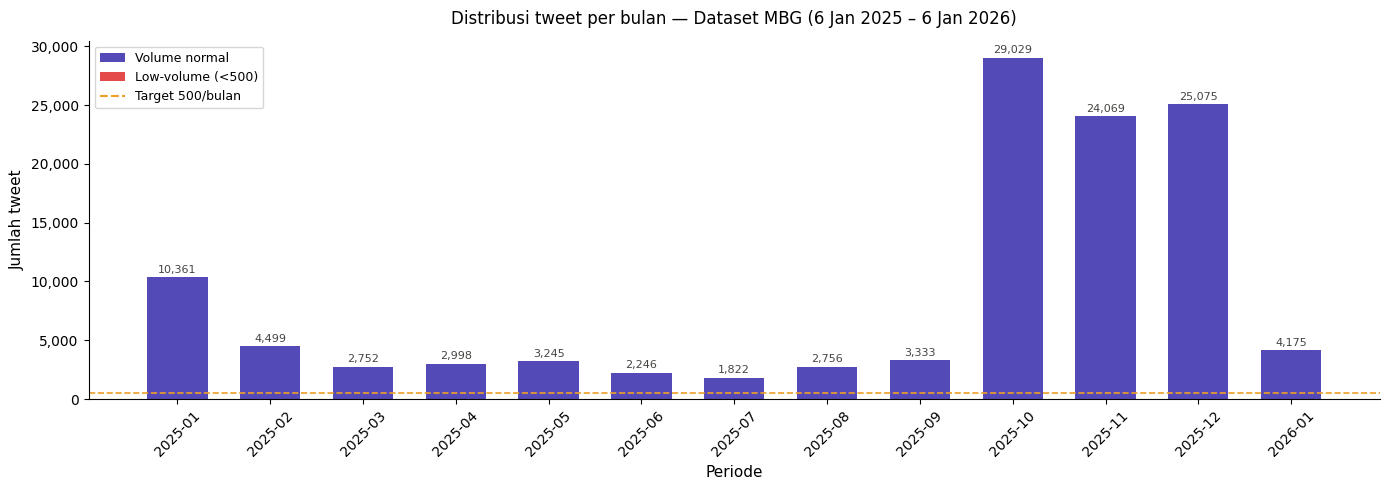

Grafik distribusi disimpan.


In [6]:
# ── Buat kolom periode bulan ──────────────────────────────────────────────────
df['period'] = df['created_at'].dt.to_period('M').astype(str)

# Validasi: hanya periode Jan-25 s/d Jan-26
valid_periods = [
    '2025-01','2025-02','2025-03','2025-04','2025-05','2025-06',
    '2025-07','2025-08','2025-09','2025-10','2025-11','2025-12','2026-01'
]
df = df[df['period'].isin(valid_periods)]

# ── Distribusi per bulan ──────────────────────────────────────────────────────
dist = df.groupby('period').size().reindex(valid_periods, fill_value=0).reset_index()
dist.columns = ['period', 'n_available']
dist['is_low_volume'] = dist['n_available'] < SAMPLE_PER_MONTH

print('=== DISTRIBUSI DATA PER BULAN (SEBELUM SAMPLING) ===')
print(dist.to_string(index=False))
print(f'\nTotal tweet tersedia: {dist["n_available"].sum():,}')
print(f'Bulan low-volume (<{SAMPLE_PER_MONTH}): {dist["is_low_volume"].sum()} bulan')

# ── Visualisasi distribusi ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = ['#E24B4A' if lv else '#534AB7' for lv in dist['is_low_volume']]
bars = ax.bar(dist['period'], dist['n_available'], color=bar_colors,
              edgecolor='none', width=0.65)

for bar, val in zip(bars, dist['n_available']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=8, color='#444441')

ax.axhline(y=SAMPLE_PER_MONTH, color='#EF9F27', linestyle='--',
           linewidth=1.2, label=f'Target sampling ({SAMPLE_PER_MONTH}/bulan)')
ax.set_xlabel('Periode', fontsize=11)
ax.set_ylabel('Jumlah tweet', fontsize=11)
ax.set_title('Distribusi tweet per bulan — Dataset MBG (6 Jan 2025 – 6 Jan 2026)',
             fontsize=12, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#534AB7', label='Volume normal'),
    Patch(facecolor='#E24B4A', label=f'Low-volume (<{SAMPLE_PER_MONTH})'),
    plt.Line2D([0],[0], color='#EF9F27', linestyle='--', label=f'Target {SAMPLE_PER_MONTH}/bulan')
]
ax.legend(handles=legend_elements, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribusi_per_bulan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik distribusi disimpan.')

## 5. Stratified Sampling

Pengambilan sampel dilakukan menggunakan strategi **equal allocation stratified sampling** dengan ketentuan:

- **Bulan normal** (n_available ≥ 500): Diambil tepat 500 sampel secara acak dengan `random_state=42` untuk memastikan reproducibility.
- **Bulan low-volume** (n_available < 500): Diambil seluruh data yang tersedia (sensus parsial). Ini berlaku terutama untuk bulan-bulan dengan aktivitas rendah dan periode parsial Januari 2026 (hanya sampai 6 Januari).

> **Justifikasi reproducibility**: Penggunaan `random_state=42` memastikan hasil sampling identik di setiap eksekusi ulang notebook, sehingga penelitian bersifat reproducible dan dapat diverifikasi.

In [7]:
sampled_frames = []
sampling_log   = []

for period in valid_periods:
    df_month = df[df['period'] == period]
    n_avail  = len(df_month)

    if n_avail == 0:
        sampling_log.append({
            'period': period, 'n_available': 0,
            'n_sampled': 0, 'sampling_rate': 0.0,
            'is_low_volume': True, 'note': 'Tidak ada data'
        })
        continue

    if n_avail >= SAMPLE_PER_MONTH:
        sampled     = df_month.sample(n=SAMPLE_PER_MONTH, random_state=RANDOM_SEED)
        n_sampled   = SAMPLE_PER_MONTH
        is_low_vol  = False
        note        = 'Random sample'
    else:
        sampled     = df_month.copy()
        n_sampled   = n_avail
        is_low_vol  = True
        note        = 'Sensus parsial (low-volume)'

    sampled_frames.append(sampled)
    sampling_log.append({
        'period'        : period,
        'n_available'   : n_avail,
        'n_sampled'     : n_sampled,
        'sampling_rate' : round(n_sampled / n_avail * 100, 2),
        'is_low_volume' : is_low_vol,
        'note'          : note
    })

# ── Gabungkan hasil sampling ──────────────────────────────────────────────────
df_sampled = pd.concat(sampled_frames, ignore_index=True)
df_log     = pd.DataFrame(sampling_log)

print('=== LAPORAN SAMPLING PER BULAN ===')
print(df_log.to_string(index=False))
print(f'\nTotal sampel terkumpul: {len(df_sampled):,} tweet')

=== LAPORAN SAMPLING PER BULAN ===
 period  n_available  n_sampled  sampling_rate  is_low_volume          note
2025-01        10361        500           4.83          False Random sample
2025-02         4499        500          11.11          False Random sample
2025-03         2752        500          18.17          False Random sample
2025-04         2998        500          16.68          False Random sample
2025-05         3245        500          15.41          False Random sample
2025-06         2246        500          22.26          False Random sample
2025-07         1822        500          27.44          False Random sample
2025-08         2756        500          18.14          False Random sample
2025-09         3333        500          15.00          False Random sample
2025-10        29029        500           1.72          False Random sample
2025-11        24069        500           2.08          False Random sample
2025-12        25075        500           1.99       

## 6. Validasi Post-Sampling & Visualisasi

Memverifikasi hasil sampling dengan membandingkan jumlah data tersedia vs sampel per bulan. Visualisasi ini akan digunakan sebagai bahan laporan di bab metodologi untuk menunjukkan distribusi sampel yang diambil.

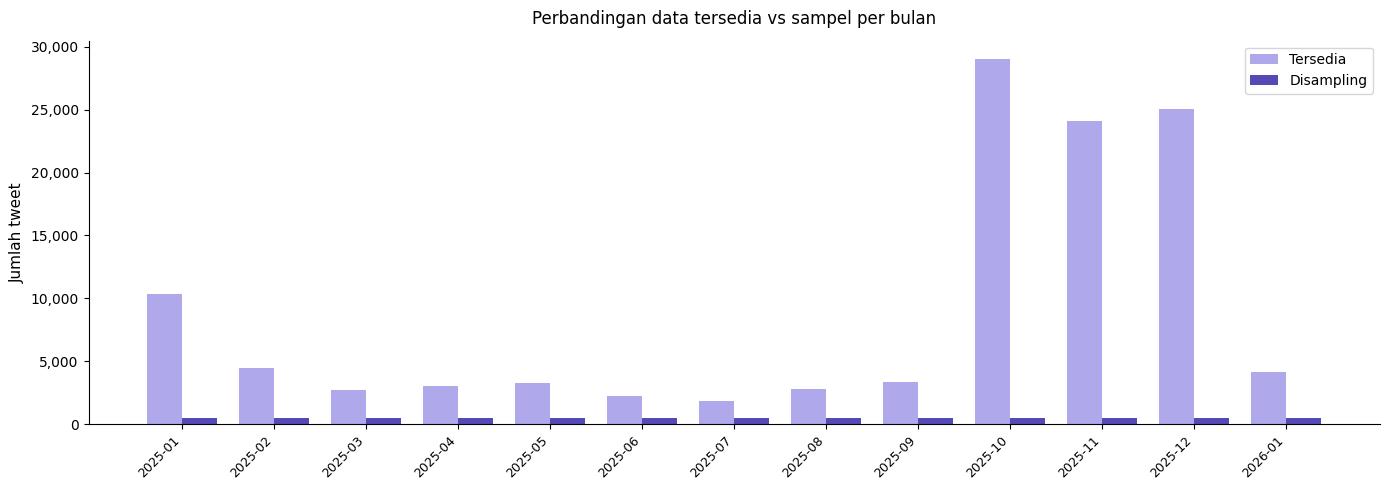

=== STATISTIK RINGKASAN SAMPLING ===
Total data tersedia setelah pre-filter : 116,360
Total sampel terkumpul                 : 6,500
Bulan normal (n ≥ 500)           : 13 bulan
Bulan low-volume (n < 500)        : 0 bulan
Overall sampling rate                  : 5.59%

=== STATISTIK PANJANG TWEET (SAMPEL) ===
Mean   : 22.73 kata
Median : 21 kata
Min    : 4 kata
Max    : 60 kata


In [8]:
# ── Visualisasi: Available vs Sampled ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(df_log))
width = 0.38

b1 = ax.bar(x - width/2, df_log['n_available'], width,
            label='Tersedia', color='#AFA9EC', edgecolor='none')
b2 = ax.bar(x + width/2, df_log['n_sampled'], width,
            label='Disampling', color='#534AB7', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(df_log['period'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Jumlah tweet', fontsize=11)
ax.set_title('Perbandingan data tersedia vs sampel per bulan', fontsize=12, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistik ringkasan ───────────────────────────────────────────────────────
print('=== STATISTIK RINGKASAN SAMPLING ===')
print(f'Total data tersedia setelah pre-filter : {df_log["n_available"].sum():,}')
print(f'Total sampel terkumpul                 : {df_log["n_sampled"].sum():,}')
print(f'Bulan normal (n ≥ {SAMPLE_PER_MONTH})           : {(~df_log["is_low_volume"]).sum()} bulan')
print(f'Bulan low-volume (n < {SAMPLE_PER_MONTH})        : {df_log["is_low_volume"].sum()} bulan')
print(f'Overall sampling rate                  : {df_log["n_sampled"].sum()/df_log["n_available"].sum()*100:.2f}%')

# Cek distribusi kata per sampel
print(f'\n=== STATISTIK PANJANG TWEET (SAMPEL) ===')
stats = df_sampled['word_count'].describe()
print(f'Mean   : {stats["mean"]:.2f} kata')
print(f'Median : {stats["50%"]:.0f} kata')
print(f'Min    : {stats["min"]:.0f} kata')
print(f'Max    : {stats["max"]:.0f} kata')

## 7. Export Output

Menyimpan hasil sampling ke file CSV pada path yang telah ditentukan. Kolom `word_count` dan `period` dipertahankan sebagai metadata tambahan yang berguna untuk analisis selanjutnya.

File yang dihasilkan:
- **`mbg_sampled.csv`**: Dataset sampel final yang siap untuk proses pelabelan manual.

In [9]:
# ── Susun kolom output final ──────────────────────────────────────────────────
output_cols = [
    'id_str', 'created_at', 'period', 'full_text', 'word_count',
    'username', 'user_id_str', 'favorite_count', 'retweet_count',
    'reply_count', 'quote_count', 'lang', 'location', 'source_keyword'
]
output_cols_exist = [c for c in output_cols if c in df_sampled.columns]
df_final = df_sampled[output_cols_exist].copy()

# Tambahkan kolom label kosong untuk proses anotasi manual
df_final['label']      = ''   # diisi manual: positive / negative / neutral
df_final['label_roberta'] = '' # diisi dari prediksi IndoRoBERTa
df_final['annotator_notes'] = '' # catatan anotator jika diperlukan

# ── Simpan ke CSV ─────────────────────────────────────────────────────────────
df_final.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')

print('=== OUTPUT BERHASIL DISIMPAN ===')
print(f'Path   : {OUTPUT_PATH}')
print(f'Shape  : {df_final.shape[0]:,} baris × {df_final.shape[1]} kolom')
print(f'Kolom  : {list(df_final.columns)}')
print(f'\nContoh 3 baris pertama:')
df_final[['id_str', 'created_at', 'period', 'full_text', 'word_count', 'label']].head(3)

=== OUTPUT BERHASIL DISIMPAN ===
Path   : /content/drive/My Drive/skripsi/dataset/mbg/processed/mbg_sampled.csv
Shape  : 6,500 baris × 17 kolom
Kolom  : ['id_str', 'created_at', 'period', 'full_text', 'word_count', 'username', 'user_id_str', 'favorite_count', 'retweet_count', 'reply_count', 'quote_count', 'lang', 'location', 'source_keyword', 'label', 'label_roberta', 'annotator_notes']

Contoh 3 baris pertama:


,id_str,created_at,period,full_text,word_count,label
0,1878293218682421598,2025-01-12 04:09:34,2025-01,"Faktor Kecemburuan Sosial, MUI Desak Pemerinta...",12,
1,1884840884472365543,2025-01-30 05:47:40,2025-01,"Kepala Seksi Intelijen, Akhmad Putra Dwi, S.H....",34,
2,1877665442158051822,2025-01-10 10:35:01,2025-01,dengan makan bergizi gratis generasi sehat sia...,13,


## 8. Summary Akhir

Ringkasan seluruh proses untuk dokumentasi dan keperluan pelaporan di bab metodologi.

In [10]:
print('=' * 55)
print(' STRATIFIED SAMPLING SUMMARY — DATASET MBG')
print('=' * 55)
print(f' Input raw data          : {df_raw.shape[0]:>10,} tweet')
print(f' Setelah filter tanggal  : {n_after_date:>10,} tweet')
print(f' Setelah filter null     : {n_after_null:>10,} tweet')
print(f' Setelah filter panjang  : {n_after_len:>10,} tweet')
print(f' ─────────────────────────────────────────────')
print(f' Total data siap sampling: {n_after_len:>10,} tweet')
print(f' Total sampel final      : {len(df_final):>10,} tweet')
print(f' Bulan tercakup          : {df_log["n_sampled"].gt(0).sum():>10} bulan')
print(f' Bulan low-volume        : {df_log["is_low_volume"].sum():>10} bulan')
print(f' Random seed             : {RANDOM_SEED:>10}')
print(f' ─────────────────────────────────────────────')
print(f' Output disimpan ke      : {OUTPUT_PATH}')
print('=' * 55)
print('\nProses sampling selesai. Langkah selanjutnya:')
print('  1. Buka mbg_sampled.csv')
print('  2. Jalankan prediksi IndoRoBERTa → isi kolom label_roberta')
print('  3. Lakukan anotasi manual → isi kolom label')
print('  4. Hitung Cohen\'s Kappa antara label dan label_roberta')

 STRATIFIED SAMPLING SUMMARY — DATASET MBG
 Input raw data          :    119,380 tweet
 Setelah filter tanggal  :    117,370 tweet
 Setelah filter null     :    117,370 tweet
 Setelah filter panjang  :    116,360 tweet
 ─────────────────────────────────────────────
 Total data siap sampling:    116,360 tweet
 Total sampel final      :      6,500 tweet
 Bulan tercakup          :         13 bulan
 Bulan low-volume        :          0 bulan
 Random seed             :         42
 ─────────────────────────────────────────────
 Output disimpan ke      : /content/drive/My Drive/skripsi/dataset/mbg/processed/mbg_sampled.csv

Proses sampling selesai. Langkah selanjutnya:
  1. Buka mbg_sampled.csv
  2. Jalankan prediksi IndoRoBERTa → isi kolom label_roberta
  3. Lakukan anotasi manual → isi kolom label
  4. Hitung Cohen's Kappa antara label dan label_roberta


---

## Catatan Metodologis untuk Laporan

### Justifikasi Jumlah Sampel
Jumlah sampel 500 tweet per bulan ditentukan berdasarkan formula Slovin dengan margin error 5%:

$$n = \frac{N}{1 + N \cdot e^2}$$

Untuk populasi rata-rata ~9.183 tweet per bulan (total 119.380 / 13 bulan) dengan $e = 0.05$:

$$n = \frac{9183}{1 + 9183 \times (0.05)^2} \approx 383$$

Target 500 sampel per bulan melampaui batas minimum ini, sehingga dinyatakan **representatif secara statistik**.

### Penanganan Bulan Low-Volume
Bulan-bulan dengan jumlah tweet tersedia < 500 (terutama periode Juni–Juli 2025 dan Januari 2026 yang merupakan periode parsial) diambil seluruh datanya. Pendekatan ini konsisten dengan prinsip bahwa sensus parsial pada subpopulasi kecil menghasilkan estimasi yang lebih akurat dibanding sub-sampling.

### Reproducibility
Seluruh proses sampling menggunakan `random_state=42` sehingga hasil dapat direproduksi secara identik pada eksekusi ulang notebook ini.

### Limitasi
Ketimpangan volume data per bulan (rasio maks/min ≈ 16×) merupakan karakteristik alami dari aktivitas percakapan di platform X yang dipengaruhi oleh kejadian tertentu terkait program MBG. Pendekatan equal allocation yang digunakan memberikan bobot temporal yang seimbang namun tidak proporsional terhadap volume percakapan aktual.